# AI331– Machine Learning Project




---


## Group Project


---


### Section M11

##### 1- Youssef Hleil Al-Juhani : 4402962
##### 2- Majed Mohammed Al-Harbi : 4403241
##### 3- Raed Abdulsalam Al-Maghdoowi : 4403569



---




## Import necessary libraries

---







In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, RocCurveDisplay, classification_report
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import xgboost as xgb

## Work Steps


1.   **Load the Dataset** : load the dataset from CSV file.
2.   **Split Features and Target** : Separate target (y) from the features (X)
3.  **Split the Data into Train and Test Sets** : Use train_test_split() with stratify=y to maintain class balance
4.    **Data preprocessing** : Handle missing values, normalize numeric features, and convert categorical features into numeric ones.
5.   **Train and Evaluate Models** : Fit models on training data, test them on test set, then evaluate performance

## **1- Load the data Dataset:**
---



 Our dataset was downloaded from the Kaggle website and it consists of data for a local bank's customers. You can download it via the link ---> [data](https://www.kaggle.com/competitions/home-credit-default-risk/overview).

note: the dataset has several files and we only choosed the file: (application_train.csv) to be our dataset


In [15]:
df = pd.read_csv("C:\\Users\\Raed1\\Downloads\\application_train (1).csv")

In [17]:
df.shape

(307511, 122)

In [19]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


**Feature Enginering**

In [22]:
# In the dataset, we have age in days
df['DAYS_BIRTH'].head()

0    -9461
1   -16765
2   -19046
3   -19005
4   -19932
Name: DAYS_BIRTH, dtype: int64

In [24]:
# we convert the age to be in years
df['YEARS_AGE'] = ((-df['DAYS_BIRTH'])/365).astype(int)

df['YEARS_AGE'].head()

0    25
1    45
2    52
3    52
4    54
Name: YEARS_AGE, dtype: int32

## **2- Split Features and Target :**
---------------------------------------------

In [27]:
y = df['TARGET']
X = df.drop('TARGET', axis=1)


[Text(0.5, 1.0, 'Target Distribution')]

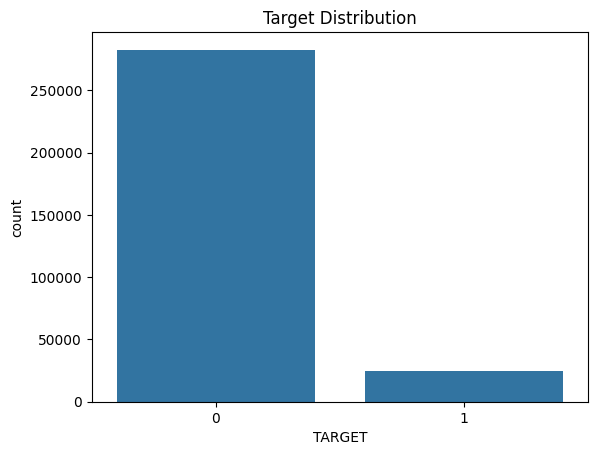

In [29]:
sns.countplot(x=df['TARGET'],).set(title='Target Distribution')
# we notice that target coulmn has imbalance distribution

## **3- Split Data into Train/Test Sets :**
----------------------------------

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## **4- Data preprocessing :**

---------------------------------------




 1- Handling missing values


In [36]:
categorical_columns = X.select_dtypes(include="object").columns
numeric_columns = X.select_dtypes(exclude="object").columns

# Fill missing values with median in numeric features
numeric_imputer = SimpleImputer(strategy='median')
X_train[numeric_columns] = numeric_imputer.fit_transform(X_train[numeric_columns])
X_test[numeric_columns] = numeric_imputer.transform(X_test[numeric_columns])

# Fill missing values with new category 'unknown' in categorical features
categorical_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
X_train[categorical_columns] = categorical_imputer.fit_transform(X_train[categorical_columns])
X_test[categorical_columns] = categorical_imputer.transform(X_test[categorical_columns])

2- Normalization and Encoding

In [39]:
scaler = StandardScaler()
encoder = OrdinalEncoder()

preprocessor = ColumnTransformer(
    [
        ("LabelEncoder", encoder, categorical_columns),
        ("StandardScaler", scaler, numeric_columns),
    ],
)


In [41]:
preprocessor

,transformers,"[('LabelEncoder', ...), ('StandardScaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,categories,'auto'
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'


In [45]:
X_train.head()

,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,YEARS_AGE
181648,310536.0,Cash loans,F,N,N,2.0,90000.0,227520.0,13189.5,180000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,33.0
229245,365516.0,Cash loans,M,Y,Y,0.0,90000.0,161730.0,13095.0,135000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0
122525,242055.0,Cash loans,M,N,Y,0.0,135000.0,728847.0,26307.0,553500.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,2.0,52.0
306311,454894.0,Cash loans,M,N,N,0.0,135000.0,474183.0,34636.5,391500.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,48.0
300658,448321.0,Cash loans,F,N,Y,0.0,180000.0,254700.0,27558.0,225000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,23.0


In [47]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [48]:
pd.DataFrame(X_train).head()

,0,1,2,3,4,5,6,7,8,9,...,112,113,114,115,116,117,118,119,120,121
0,0.0,0.0,0.0,0.0,6.0,1.0,1.0,1.0,1.0,8.0,...,-0.0247,-0.022457,-0.017923,-0.070486,-0.057891,-0.154893,-0.269136,1.337889,-0.439962,-0.871450
1,0.0,1.0,1.0,1.0,6.0,1.0,4.0,1.0,1.0,4.0,...,-0.0247,-0.022457,-0.017923,-0.070486,-0.057891,-0.154893,-0.269136,-0.396179,-0.439962,-0.118412
2,0.0,1.0,0.0,1.0,5.0,7.0,4.0,3.0,1.0,8.0,...,-0.0247,-0.022457,-0.017923,-0.070486,-0.057891,10.304899,-0.269136,-0.396179,0.126861,0.718296
3,0.0,1.0,0.0,0.0,6.0,1.0,4.0,3.0,1.0,8.0,...,-0.0247,-0.022457,-0.017923,-0.070486,-0.057891,-0.154893,-0.269136,-0.396179,1.260507,0.383612
4,0.0,0.0,0.0,1.0,6.0,1.0,2.0,3.0,1.0,0.0,...,-0.0247,-0.022457,-0.017923,-0.070486,-0.057891,-0.154893,-0.269136,-0.396179,-0.439962,-1.708158


## **5- Train and Test Models**

---



 ### **First Model: (Decision Tree)**

--------------




In [54]:
model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [56]:
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

# we notice that class weight 'balanced' did not solve the class imbalance problem.

              precision    recall  f1-score   support

           0       0.92      0.92      0.92     56538
           1       0.14      0.15      0.15      4965

    accuracy                           0.86     61503
   macro avg       0.53      0.54      0.53     61503
weighted avg       0.86      0.86      0.86     61503

AUC: 0.5350954078528474


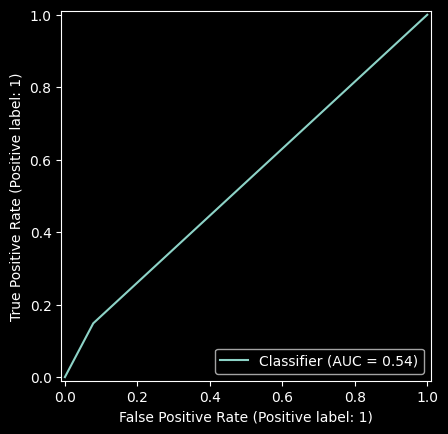

In [57]:
plt.style.use("dark_background")
RocCurveDisplay.from_predictions(
    y_test,
    model.predict_proba(X_test)[:, 1]
)

### **Second Model: (Random Forest)**
--------------




In [72]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [73]:
print(classification_report(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.38      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.65      0.50      0.48     61503
weighted avg       0.88      0.92      0.88     61503

AUC: 0.7434304359887068


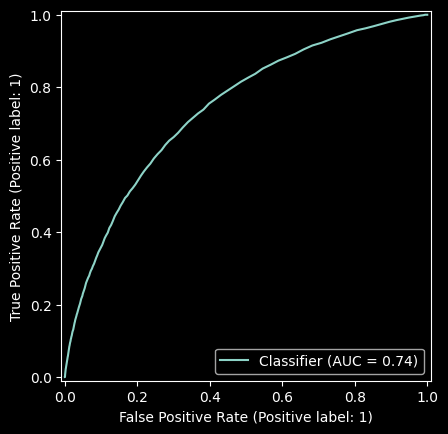

In [74]:
RocCurveDisplay.from_predictions(
    y_test,
    rf_model.predict_proba(X_test)[:, 1]
)


### **Third model: (Logistic Regression)**

---



In [81]:
LR_model = LogisticRegression( random_state=42, n_jobs=-1, class_weight='balanced', C=0.1)

LR_model.fit(X_train, y_train)

y_pred_LR = LR_model.predict(X_test)
y_prob_LR = LR_model.predict_proba(X_test)[:,1]

In [82]:
print(classification_report(y_test, y_pred_LR))
print("AUC:", roc_auc_score(y_test, y_prob_LR))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.89      0.69      0.76     61503

AUC: 0.7446615608491817


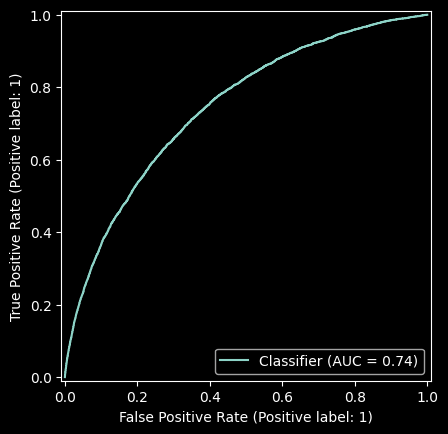

In [83]:
RocCurveDisplay.from_predictions(
    y_test,
    LR_model.predict_proba(X_test)[:, 1]
)

## Hypermeter Tuning for the most promising model according to Recall metric: (Logistic Regression)

In [ ]:
print(f"---------------- Hyper Parameter Tuning -------------------")


LR_params = {
'C' : [100, 10, 1.0, 0.1, 0.01],
'solver' : ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
}

random = RandomizedSearchCV(estimator=LogisticRegression(random_state=42, class_weight='balanced'),
                                   param_distributions=LR_params,
                                   n_iter=20,
                                   cv=3,
                                   verbose=0,
                                   random_state=42,
                                   n_jobs=-1,
                                   scoring = 'recall')

print(f"---------------- Best Params -------------------")
random.fit(X_train, y_train)
print(random.best_params_)

---------------- Hyper Parameter Tuning -------------------
---------------- Best Params -------------------
{'solver': 'newton-cg', 'C': 100}


In [ ]:
LR_model_2 = random.best_estimator_

LR_model_2.fit(X_train, y_train)

LogisticRegression(C=100, class_weight='balanced', random_state=42,
                   solver='newton-cg')

In [ ]:
y_pred_LR_2 = LR_model_2.predict(X_test)
y_prob_LR_2 = LR_model_2.predict_proba(X_test)[:,1]

In [ ]:
print(classification_report(y_test, y_pred_LR_2))
print("AUC:", roc_auc_score(y_test, y_prob_LR_2))

              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

AUC: 0.7468888074528706
